# Capstone 2: Probability of Default (PD) Model

## 1. Project Overview
This project aims to build a predictive model to estimate the probability of loan delinquency using LendingClub data.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv
/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/LCDataDictionary.xlsx


In [2]:

#Checking the dataset directory
os.listdir('/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv')

['loan.csv', 'LCDataDictionary.xlsx']

## 2. Data Loading and Initial Exploration

We begin by loading the full LendingClub dataset from Kaggle and examining its dimensions. The dataset contains 2,260,668 rows and 145 columns. To improve computational efficiency, a random sample of 50,000 observations is selected using a fixed random seed (random_state = 42). Random sampling helps ensure that the sample reflects the overall distribution of the original dataset while significantly reducing processing time during data cleaning, exploratory analysis, and model development.

Before loading the data, we verify the dataset directory to confirm the presence of the main dataset file and the accompanying data dictionary. The sampled dataset is then inspected to examine its dimensions, column names, data types, and overall structure before proceeding with preprocessing and feature engineering.

In [3]:
import pandas as pd
# Load te full Lending Club dataset
df = pd.read_csv(
    '/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv',
    low_memory = False
)

df.shape


(2260668, 145)

In [4]:
# Take a random sample of 50,000 rows
df_sample = df.sample(
    n = 50000, 
    random_state = 42
)
df_sample.head()


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
1758049,NaN,NaN,35000,35000,35000.0,36 months,12.12,1164.51,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
686533,NaN,NaN,30000,30000,30000.0,60 months,10.75,648.54,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
900721,NaN,NaN,15000,15000,15000.0,36 months,7.49,466.53,A,A4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1727912,NaN,NaN,24000,24000,24000.0,60 months,21.15,651.31,E,E2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
539691,NaN,NaN,14400,14400,14400.0,36 months,8.59,455.18,A,A5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_sample.shape

(50000, 145)

In [6]:
# Checking all the columns
pd.set_option('display.max_columns', None)
list(df_sample.columns)

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_

In [7]:
df_sample['loan_status'].value_counts()

loan_status
Fully Paid                                             23097
Current                                                20279
Charged Off                                             5778
Late (31-120 days)                                       487
In Grace Period                                          203
Late (16-30 days)                                         88
Does not meet the credit policy. Status:Fully Paid        43
Does not meet the credit policy. Status:Charged Off       24
Default                                                    1
Name: count, dtype: int64

The `loan_status` column contains different loan outcome categories, such as *Current*, *Fully Paid*, *Charged Off*, and *Default*. Using `value_counts()` provides the frequency of each category within the sampled dataset. 

## 3. Initial Data Cleaning and Dataset Refinement
This section focuses on preparing and refining the dataset prior to exploratory analysis and predictive modeling. The process includes defining the target variable, removing potential data leakage features, examining missing values, reviewing data types, and transforming variables into formats suitable for analysis. Additional feature refinement steps are performed to reduce noise, improve data quality, and ensure that the remaining variables reflect information available at the time of loan origination

## 3.1 Target Variable Creation and Distribution

The `loan_status` variable represents the current or final repayment status of each loan and serves as the foundation for defining the target variable in this analysis. The objective of this project is to predict loan default using a definition that aligns more closely with real-world credit risk practices. Under this approach, only loans that resulted in a final default outcome were classified as defaults.

To construct the binary target variable, loans were categorized into two groups based on their final repayment outcomes. Loans with a status of **“Charged Off”**, **“Default”**, or **“Does not meet the credit policy: Status: Charged Off”** were classified as `default loans` (bad_status = 1). All remaining loan statuses, including **“Fully Paid”**, **“Current”**, **“In Grace Period”**, and delinquent statuses such as **“Late (16–30 days)”** and **“Late (31–120 days)”**, were classified as `non-default` loans (bad_status = 0).

This classification reflects the distinction between borrowers who ultimately defaulted on their obligations and those who did not. While some loans may experience temporary delinquency, late payment alone does not necessarily result in default. The binary target variable therefore focuses on realized default events, providing a more realistic framework for credit risk modeling.

In [8]:
# Defining categories

bad_status = [
    'Charged Off',
    'Does not meet the credit policy. Status:Charged Off',
    'Default'
]

good_status = [
    'Fully Paid',
    'Current',
    'Late (31-120 days)',
    'In Grace Period',
    'Late (16-30 days)',
    'Does not meet the credit policy. Status:Fully Paid'
]

In [9]:
# Creating a binary target

df_sample['bad_status'] = df['loan_status'].apply(lambda x:1 if x in bad_status else 0)

In [10]:
# Check the result
df_sample['bad_status'].value_counts()

bad_status
0    44197
1     5803
Name: count, dtype: int64

In [11]:
# Checking the proportion of Default vs Non-Default
df_sample['bad_status'].value_counts(normalize = True)

bad_status
0    0.88394
1    0.11606
Name: proportion, dtype: float64

After defining the binary target variable `bad_status`, the distribution of loan outcomes was examined using the `value_counts()` method, which counts the number of occurrences of each unique value in the column. The result shows that the majority of loans are classified as non-default (0), with 44,197 observations out of 50,000 sample, and 5,803 loans are classified as default (1).

This indicates that the dataset is moderately imbalanced, with approximately 88.4% non-default loans and 11.6% default loans. Such class imbalance is common in credit risk datasets, as only a minority of borrowers ultimately default on their loans.

## 3.2 Removal of Data Leakage Features and Target Variable 


Certain variables were removed from the dataset due to potential data leakage, as they contain information that becomes available only after the loan has been issued or after repayment behavior has already occurred. Including such variables would result in unrealistic model performance, since they effectively reveal the outcome of the loan.

Examples of these variables include total payment amounts, recovery-related metrics, and last payment information, all of which are directly influenced by whether a borrower ultimately defaults. To ensure that the model reflects a real-world prediction scenario at the time of loan origination, these columns were excluded from the analysis.

The following variables were identified as containing post-outcome or repayment-related information and were therefore removed: total payment variables (total_pymnt, total_pymnt_inv), recovery-related variables (recoveries, collection_recovery_fee), repayment components (total_rec_prncp, total_rec_int, total_rec_late_fee), and variables reflecting repayment timing and remaining balance (last_pymnt_d, last_pymnt_amnt, out_prncp, out_prncp_inv).

In [12]:
# Creating leakage list:

leakage_cols = [
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'out_prncp',
    'out_prncp_inv'
]

In [13]:
# Dropping the leakage columns from our dataset:

df_sample = df_sample.drop(columns = leakage_cols, errors = 'ignore')

### Removal of Target Variable Source

After constructing the binary target variable bad_status, the original loan_status column has to be removed from the dataset. This is because loan_status directly reflects the final outcome of each loan and was used to derive the target variable. Keeping this column in the dataset would introduce target leakage, allowing the model to trivially infer the outcome and resulting in misleading performance. Therefore, it was excluded to ensure that the model relies only on independent features available at the time of loan origination.

In [14]:
# Dropping 'loan_status' since we have our binary variable 
df_sample = df_sample.drop(columns=['loan_status'], errors='ignore')

In [15]:
# Checking the new shape of the dataset:
df_sample.shape

(50000, 134)

After filtering the dataset and removing leakage variables and target variable source "loan_status", the number of columns decreased from 145 to 134. Although 12 leakage columns were removed, one new binary target column, `default`, was added, resulting in a net reduction of 11 columns.

## 3.3 Initial Missing Values Assessment and Column Filtering

To understand the quality of the dataset, we need to examine missing values across all columns. I used the *isnull().sum()* function to count how many missing values were present in each variable and sort the results to identify the columns with the most missing data. After, I calculated the percentage of missing values relative to the total number of rows. These results were be combined into a new DataFrame (`missing_df_sample`) to clearly summarize and analyze the extent of missing data in the dataset.

In [16]:
# Counting how many missing values are in each variable with isnull().sum()
missing = df_sample.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df_sample)) * 100

missing_df_sample = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_percent
})

missing_df_sample.head(20)

,missing_count,missing_percent
id,50000,100.000
member_id,50000,100.000
url,50000,100.000
orig_projected_additional_accrued_interest,49803,99.606
hardship_last_payment_amount,49763,99.526
hardship_length,49763,99.526
payment_plan_start_date,49763,99.526
hardship_dpd,49763,99.526
hardship_payoff_balance_amount,49763,99.526
hardship_loan_status,49763,99.526


In [17]:
# 20% threshold (dropping high - missing columns (>20%))
cols_20 = missing_df_sample[missing_df_sample['missing_percent'] > 20].index
df_sample_20 = df_sample.drop(columns=cols_20)
df_sample_20.shape

(50000, 76)

In [18]:
# Assigning 20% threshold missingness to our sample of dataset
df_sample = df_sample_20.copy()

In [19]:
df_sample.shape

(50000, 76)

A 20% threshold was selected to balance data quality and feature retention. The resulting dataset retained 76 features while significantly reducing missingness.

In [20]:
# Check the remaining missing values:
df_sample.isnull().sum().sort_values(ascending = False).head(10)

mths_since_recent_inq    6634
emp_title                3669
num_tl_120dpd_2m         3415
emp_length               3220
mo_sin_old_il_acct       3112
bc_util                  1710
percent_bc_gt_75         1688
bc_open_to_buy           1681
mths_since_recent_bc     1653
pct_tl_nvr_dlq           1587
dtype: int64

After applying a 20% missing value threshold, variables with extremely high levels of missing data were removed from the dataset. The remaining features exhibit moderate levels of missingness, generally below 20%.

Many of these variables are related to borrower behavior and credit activity, such as recent inquiries and delinquency measures. In some cases, missing values may not be random but instead reflect the absence of a specific event (e.g., no recent credit inquiries). Therefore, these variables were retained, and their missing values will be handled carefully during imputation to preserve potentially useful information for modeling.

## 3.4 Dataset Refinement

At this stage, the dataset is refined by removing variables that are unlikely to improve model performance or that could introduce bias into the predictive model. The objective is to retain only features that are relevant and appropriate for predicting loan default while eliminating unnecessary information before handling missing values and model development.

Several variables are removed because they provide little predictive value, contain high-cardinality text, remain nearly constant across observations, or represent information unavailable at the time a loan application is evaluated. Removing these variables simplifies the dataset, reduces noise, and helps prevent data leakage.

Specifically, identifier and text-based variables such as zip_code, title, and emp_title are excluded because they contain thousands of unique values with limited generalizability. Variables such as pymnt_plan and policy_code are removed because they exhibit little variation and contribute minimal predictive information.

Additionally, last_credit_pull_d and debt_settlement_flag are excluded because they contain information generated after loan origination. Including these variables would allow the model to learn from future information that would not be available when making real-world lending decisions, resulting in data leakage.

After completing feature refinement, the remaining dataset is used for missing-value analysis, imputation, and subsequent preprocessing before model training.

In [21]:
# Dropping columns with low predictive value, high noise, or potential data leakage

drop_cols = [
    'zip_code',
    'title',
    'emp_title',
    'pymnt_plan',
    'policy_code',
    'debt_settlement_flag'
]

df_sample = df_sample.drop(columns=drop_cols)

In [22]:
# Drop last_credit_pull_d as it contains information from after loan origination, 
# which would introduce data leakage into the model:

df_sample = df_sample.drop(columns=['last_credit_pull_d'])

In [23]:
print(f'Remaining columns: {df_sample.shape[1]}')

Remaining columns: 69


In [24]:
# Columns with no missing values:
no_missing_cols = df_sample.columns[df_sample.isnull().sum() == 0]

# Columns with missing values:
missing_cols = df_sample.columns[df_sample.isnull().sum() > 0]

In [25]:
# Checking the amount of each:
len(no_missing_cols)

28

In [26]:
len(missing_cols)

41

In [27]:
# Split missing columns by type:
missing_num_cols = df_sample[missing_cols].select_dtypes(include=['int64', 'float64']).columns
missing_cat_cols = df_sample[missing_cols].select_dtypes(include=['object']).columns

In [28]:
# Printing columns with missing values separately numerical from categorical
print("Numerical columns with missing values:")
print(list(missing_num_cols))

print("\nCategorical columns with missing values:")
print(list(missing_cat_cols))

Numerical columns with missing values:
['dti', 'revol_util', 'collections_12_mths_ex_med', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit']

Categorical columns with missing values:
['emp_length']


In [29]:
# Starting with categorical column 'emp_length':
df_sample['emp_length'].head(20)

1758049     < 1 year
686533       2 years
900721       5 years
1727912      5 years
539691       3 years
2153213     < 1 year
47643         1 year
1360732      9 years
1779694    10+ years
511378       3 years
506300       5 years
1262689    10+ years
1094496          NaN
578794      < 1 year
1421198      2 years
1228621      9 years
992325       4 years
93762        9 years
754133       5 years
1815417      5 years
Name: emp_length, dtype: object

In [30]:
df_sample['emp_length'].isnull().sum()

np.int64(3220)

In [31]:
# Inspecting unique values first:

sorted(df_sample['emp_length'].dropna().unique())

['1 year',
 '10+ years',
 '2 years',
 '3 years',
 '4 years',
 '5 years',
 '6 years',
 '7 years',
 '8 years',
 '9 years',
 '< 1 year']

In [32]:
# Step 1: Converting special cases to string numbers (not integers!)
df_sample['emp_length'] = df_sample['emp_length'].replace({
    '< 1 year': '1',
    '10+ years': '10'
})

# Step 2: Removing text
df_sample['emp_length'] = df_sample['emp_length'].str.replace(' years', '', regex=False)
df_sample['emp_length'] = df_sample['emp_length'].str.replace(' year', '', regex=False)
df_sample['emp_length'] = df_sample['emp_length'].str.strip()

# Step 3: Converting to numeric
df_sample['emp_length'] = pd.to_numeric(df_sample['emp_length'], errors='coerce')

In [33]:
# Verifying that the amount of NaN is the same as before
df_sample['emp_length'].isnull().sum()

np.int64(3220)

Approximately 6.4% of observations (3,220 out of 50,000) have missing values in the employment length variable. Since this proportion is relatively small and employment history is an important indicator of borrower stability, the variable is going to be retained. The categorical values will be converted into numeric form, and a separate binary indicator is going to be created to capture missing employment information, allowing the model to learn whether missingness itself is predictive of default risk.

In [34]:
# Another check that everything besides the NaN converted correctly:
df_sample['emp_length'].value_counts(dropna=False)

emp_length
10.0    16646
1.0      7492
2.0      4493
3.0      4011
NaN      3220
5.0      3027
4.0      3006
6.0      2278
7.0      2066
8.0      2021
9.0      1740
Name: count, dtype: int64

In [35]:
# Create a binary indicator to capture missing employment length, 
# allowing the model to learn from missingness:

df_sample['emp_length_missing'] = df_sample['emp_length'].isnull().astype(int)

In [36]:
# Checking the column:
df_sample['emp_length_missing'].value_counts()

emp_length_missing
0    46780
1     3220
Name: count, dtype: int64

In [37]:
# Replace missing employment length values with -1 in the original emp_length column
# to retain observations for modeling :

df_sample['emp_length'] = df_sample['emp_length'].fillna(-1)

In [38]:
# Making sure there is no more missing values in the column:
df_sample['emp_length'].isnull().sum()

np.int64(0)

In [39]:
# Checking the new values of the column, there should be 3220 of -1
df_sample['emp_length'].value_counts(dropna=False)

emp_length
 10.0    16646
 1.0      7492
 2.0      4493
 3.0      4011
-1.0      3220
 5.0      3027
 4.0      3006
 6.0      2278
 7.0      2066
 8.0      2021
 9.0      1740
Name: count, dtype: int64

## 3.6 Missing Value Imputation Strategy

To handle the remaining missing values in the dataset, variables are going to be grouped according to their meaning rather than treated individually. This approach ensures that missing data are filled in a way that is consistent with the underlying financial interpretation of each feature.

Event-based variables, such as counts of inquiries, delinquencies, charge-offs, bankruptcies, or tax liens, are imputed with zero because missing values in these cases are interpreted as the absence of the event. Time-based variables that measure the number of months since a financial event are imputed with -1, which is used as a placeholder to indicate that the event has never occurred. Continuous financial variables, such as balances, credit limits, utilization measures, and other numeric account-level characteristics, are imputed using the median to preserve the overall distribution of the data while reducing sensitivity to outliers.

This grouped imputation strategy provides a structured and defensible way to complete the dataset for modeling without relying on a single rule for all variables.

In [40]:
# Event-based variables: missing values indicate that no event occurred,
# so they are safely imputed with 0

event_cols = [
    'inq_last_6mths',
    'collections_12_mths_ex_med',
    'chargeoff_within_12_mths',
    'num_accts_ever_120_pd',
    'num_tl_30dpd',
    'num_tl_90g_dpd_24m',
    'num_tl_120dpd_2m',
    'pub_rec_bankruptcies',
    'tax_liens'
]


# Keep only columns that still exist in the dataset
event_cols = [col for col in event_cols if col in df_sample.columns]

df_sample[event_cols] = df_sample[event_cols].fillna(0)

In [41]:
# Checking one of the event-based columns
df_sample['inq_last_6mths'].value_counts()

inq_last_6mths
0.0     30599
1.0     12848
2.0      4418
3.0      1542
4.0       416
5.0       141
6.0        29
10.0        3
8.0         2
9.0         1
7.0         1
Name: count, dtype: int64

In [42]:
# Time-based variables: missing values indicate that the event has never occurred,
# so they are imputed with -1 to explicitly capture this condition

time_cols = [
    'mo_sin_old_il_acct',
    'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl',
    'mths_since_recent_bc',
    'mths_since_recent_inq'
]

df_sample[time_cols] = df_sample[time_cols].fillna(-1)

In [43]:
# Checking one of the time-based variables:
df_sample['mo_sin_old_il_acct'].value_counts()

mo_sin_old_il_acct
-1.0      3112
 137.0     572
 127.0     567
 128.0     565
 133.0     565
          ... 
 362.0       1
 406.0       1
 407.0       1
 372.0       1
 377.0       1
Name: count, Length: 398, dtype: int64

In [44]:
# Continuous numeric columns: missing values are imputed using the median
# to preserve the distribution and reduce the influence of outliers

continuous_cols = [
    col for col in missing_num_cols
    if col not in event_cols + time_cols
]

df_sample[continuous_cols] = df_sample[continuous_cols].fillna(df[continuous_cols].median())

In [45]:
# Grouping all of the columns with treated missing values together:

treated_num_cols = event_cols + time_cols + continuous_cols

In [46]:
# Checking if there are any left out columns:

left_out_num_cols = [col for col in missing_num_cols if col not in treated_num_cols]
print(left_out_num_cols)

[]


In [47]:
# Checking the overview off the dataset:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 1758049 to 1163744
Data columns (total 70 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_amnt                   50000 non-null  int64  
 1   funded_amnt                 50000 non-null  int64  
 2   funded_amnt_inv             50000 non-null  float64
 3   term                        50000 non-null  object 
 4   int_rate                    50000 non-null  float64
 5   installment                 50000 non-null  float64
 6   grade                       50000 non-null  object 
 7   sub_grade                   50000 non-null  object 
 8   emp_length                  50000 non-null  float64
 9   home_ownership              50000 non-null  object 
 10  annual_inc                  50000 non-null  float64
 11  verification_status         50000 non-null  object 
 12  issue_d                     50000 non-null  object 
 13  purpose                     

Variables that measure the timing of credit-related events, such as those starting with `mo_sin_` or `mths_since_`, represent the number of months since specific events (e.g., account openings or recent activity).

These variables capture the length and recency of a borrower’s credit history. In many cases, missing values in these fields indicate that the event has never occurred rather than simply being unreported.

To preserve this distinction, missing values are imputed with -1, explicitly encoding the absence of the event. This allows the model to differentiate between recent activity, older activity, and no recorded occurrence.

In contrast, continuous financial variables and account-level characteristics, including account counts such as mortgage accounts (`mort_acc`), are imputed using the median, as missing values in these variables reflect incomplete reporting rather than the absence of activity.

## 3.7 Variable Encoding and Feature Transformation
This section focuses on transforming and encoding variables into formats suitable for analysis and predictive modeling. Object-type variables are examined to determine whether they represent categorical information, numerical values stored as text, or date-related features requiring specialized treatment. Several variables are converted into numerical representations, including transformations of date variables into time-based features and mappings of ordinal credit grading variables into structured numerical formats. Additional preprocessing steps include the creation of binary indicator variables, conversion of boolean variables into integers, and one-hot encoding of categorical features using dummy variables. These transformations help standardize the dataset and prepare all remaining variables for exploratory analysis and machine learning modeling.

In [48]:
# Extract all columns with object data type
object_cols = df_sample.select_dtypes(include='object').columns.tolist()

# Print them
object_cols

['term',
 'grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'issue_d',
 'purpose',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'application_type',
 'hardship_flag',
 'disbursement_method']

In [49]:
# Taking a look at our "object" columns:
df_sample[object_cols].head(100)

,term,grade,sub_grade,home_ownership,verification_status,issue_d,purpose,addr_state,earliest_cr_line,initial_list_status,application_type,hardship_flag,disbursement_method
1758049,36 months,B,B3,RENT,Verified,Jun-2013,debt_consolidation,TX,Nov-1997,w,Individual,N,Cash
686533,60 months,B,B4,RENT,Verified,Apr-2016,credit_card,TX,Jun-2011,f,Individual,N,Cash
900721,36 months,A,A4,OWN,Source Verified,Oct-2016,small_business,MD,Apr-1996,w,Individual,N,Cash
1727912,60 months,E,E2,RENT,Source Verified,Sep-2013,debt_consolidation,NC,Aug-1998,f,Individual,N,Cash
539691,36 months,A,A5,MORTGAGE,Not Verified,Aug-2016,debt_consolidation,MO,Dec-2003,w,Individual,N,Cash
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515713,60 months,B,B5,MORTGAGE,Verified,Sep-2016,debt_consolidation,MA,Aug-1988,w,Individual,N,Cash
755134,60 months,C,C4,MORTGAGE,Not Verified,Feb-2016,debt_consolidation,IL,Aug-2003,w,Individual,N,Cash
765186,36 months,A,A2,MORTGAGE,Not Verified,Feb-2016,home_improvement,MO,Aug-2003,w,Individual,N,Cash
543113,60 months,C,C4,RENT,Not Verified,Aug-2016,vacation,FL,Nov-1986,w,Individual,N,Cash


In [50]:
# Converting term column to numeric:
df_sample['term'] = df_sample['term'].str.extract(r'(\d+)').astype(int)

In [51]:
# Checking the 'term' column:
df_sample['term'].head()

1758049    36
686533     60
900721     36
1727912    60
539691     36
Name: term, dtype: int64

In [52]:
# Convert date variables to datetime:

df_sample['issue_d'] = pd.to_datetime(df_sample['issue_d'])
df_sample['earliest_cr_line'] = pd.to_datetime(df_sample['earliest_cr_line'])

/tmp/ipykernel_58/659374769.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sample['issue_d'] = pd.to_datetime(df_sample['issue_d'])
/tmp/ipykernel_58/659374769.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sample['earliest_cr_line'] = pd.to_datetime(df_sample['earliest_cr_line'])


In [53]:
df_sample['issue_d'].head()

1758049   2013-06-01
686533    2016-04-01
900721    2016-10-01
1727912   2013-09-01
539691    2016-08-01
Name: issue_d, dtype: datetime64[ns]

In [54]:
df_sample['earliest_cr_line'].head()

1758049   1997-11-01
686533    2011-06-01
900721    1996-04-01
1727912   1998-08-01
539691    2003-12-01
Name: earliest_cr_line, dtype: datetime64[ns]

In [55]:
# Checking "initial_list_status" if theres any value in this column:
df_sample['initial_list_status'].value_counts()

initial_list_status
w    34024
f    15976
Name: count, dtype: int64

The variable `initial_list_status` indicates how the loan was funded at origination. 
A value of 'w' (whole loan) means the loan was funded by a single investor or institution, 
while 'f' (fractional) means the loan was split across multiple investors. This feature 
may capture differences in loan structure and investor behavior, which could potentially 
influence default risk. 

For modeling purposes, the variable is converted into a binary numeric format, where 
'w' is mapped to 1 and 'f' is mapped to 0, allowing it to be used in machine learning algorithms.

In [56]:
# Creating a numerical binary variable:
df_sample['initial_list_status'] = df['initial_list_status'].map({'w': 1, 'f': 0})

In [57]:
# Quick check:
df_sample['initial_list_status'].value_counts()

initial_list_status
1    34024
0    15976
Name: count, dtype: int64

The variables `grade` and `sub_grade` represent borrower credit quality at different levels of detail. The `grade` variable provides a broad classification from A to G, while `sub_grade` offers a finer ranking within each grade. 

To prepare these variables for modeling, `grade` is converted into a numeric scale from 1 to 7, and the numeric component of `sub_grade` is extracted to represent the relative position within each grade. Both variables are retained to preserve interpretability while enabling their use in numerical models.

In [58]:
# Convert grade to numeric scale (A=1, ..., G=7)
df_sample['grade'] = df_sample['grade'].map({
    'A': 1, 'B': 2, 'C': 3, 'D': 4,
    'E': 5, 'F': 6, 'G': 7
})

In [59]:
# Quick check:
df_sample['grade'].value_counts().sort_index()

grade
1     9600
2    14473
3    14434
4     7226
5     3082
6      913
7      272
Name: count, dtype: int64

In [60]:
# Extract numeric part of sub_grade (A1 → 1, B3 → 3, etc.):

df_sample['sub_grade'] = df_sample['sub_grade'].str.extract(r'(\d+)').astype(int)

In [61]:
# Quick check:
df_sample['sub_grade'].value_counts().sort_index()

sub_grade
1    10936
2     9740
3     9639
4     9961
5     9724
Name: count, dtype: int64

In [62]:
# Combine grade and sub_grade into a single ordered variable
df_sample['grade_combined'] = df_sample['grade'] + df_sample['sub_grade'] / 10

In [63]:
# Quick check:
df_sample['grade_combined'].value_counts().sort_index()

grade_combined
1.1    1960
1.2    1577
1.3    1572
1.4    2088
1.5    2403
2.1    2781
2.2    2724
2.3    2864
2.4    3049
2.5    3055
3.1    3320
3.2    2894
3.3    2829
3.4    2836
3.5    2555
4.1    1746
4.2    1610
4.3    1518
4.4    1306
4.5    1046
5.1     734
5.2     681
5.3     641
5.4     517
5.5     509
6.1     297
6.2     204
6.3     166
6.4     124
6.5     122
7.1      98
7.2      50
7.3      49
7.4      41
7.5      34
Name: count, dtype: int64

In [64]:
# Creating numerical binary variable for 'hardship_flag':

df_sample['hardship_flag'] = df_sample['hardship_flag'].map({'N': 0, 'Y': 1})

In [65]:
# Checking the column:
df_sample['hardship_flag'].value_counts().sort_index()

hardship_flag
0    49974
1       26
Name: count, dtype: int64

In [66]:
# Converting 'application_type' to binary numerical:

df_sample['application_type'] = df_sample['application_type'].map({
    'Individual': 0,
    'Joint App': 1
})

df_sample['application_type'].value_counts()

application_type
0    47322
1     2678
Name: count, dtype: int64

The variable `disbursement_method` indicates how loan funds were distributed to the borrower. 
A value of 'Cash' means the borrower received the funds directly, while 'DirectPay' indicates 
that the funds were sent directly to creditors (e.g., to pay off existing debt). Although the 
variable is highly imbalanced, it is retained as it may capture differences in borrower behavior 
and loan usage that could influence default risk.

In [67]:
# Looking at the 'disbursement_method' variable

df_sample['disbursement_method'].value_counts()

disbursement_method
Cash         48269
DirectPay     1731
Name: count, dtype: int64

In [68]:
# Converting to binary numerical:

df_sample['disbursement_method'] = df_sample['disbursement_method'].map({
    'Cash': 0,
    'DirectPay': 1
})

df_sample['disbursement_method'].value_counts()

disbursement_method
0    48269
1     1731
Name: count, dtype: int64

After converting key variables into numeric format, the remaining categorical features are examined individually. Binary variables such as `hardship_flag` and `application_type` are encoded into numeric form. Other categorical variables, including `home_ownership`, `verification_status`, and `purpose`, are inspected to understand their distributions before deciding on appropriate encoding or transformation strategies.

In [69]:
df_sample['home_ownership'].value_counts()

home_ownership
MORTGAGE    24385
RENT        20019
OWN          5574
ANY            17
OTHER           4
NONE            1
Name: count, dtype: int64

In [70]:
# Grouping the rare ones under "OTHER":
df_sample['home_ownership'] = df_sample['home_ownership'].replace({
    'ANY': 'OTHER',
    'NONE': 'OTHER'
})

In [71]:
# Checking the outcome:
df_sample['home_ownership'].value_counts()

home_ownership
MORTGAGE    24385
RENT        20019
OWN          5574
OTHER          22
Name: count, dtype: int64

In [72]:
df_sample['verification_status'].value_counts()

verification_status
Source Verified    19545
Not Verified       16391
Verified           14064
Name: count, dtype: int64

In [73]:
pd.crosstab(
    df_sample['verification_status'],
    df_sample['bad_status'],
    normalize='index'
)

bad_status,0,1
verification_status,,
Not Verified,0.922579,0.077421
Source Verified,0.879969,0.120031
Verified,0.844425,0.155575


Among Not Verified loans, 7.7% defaulted.
Among Source Verified loans, 12.0% defaulted.
Among Verified loans, 15.6% defaulted.

In [74]:
# Mapping verification status to numeric values for modeling

df_sample['verification_status'] = df_sample['verification_status'].map({
    'Not Verified': 0,
    'Source Verified': 1,
    'Verified': 2
})

# Checking the outcome:
df_sample['verification_status'].value_counts()

verification_status
1    19545
0    16391
2    14064
Name: count, dtype: int64

In [75]:
df_sample['purpose'].value_counts()

purpose
debt_consolidation    28188
credit_card           11447
home_improvement       3318
other                  3216
major_purchase         1068
medical                 587
small_business          560
car                     545
vacation                350
moving                  336
house                   300
wedding                  55
renewable_energy         26
educational               4
Name: count, dtype: int64

In [76]:
# Group detailed loan purposes into broader categories 
# to reduce dimensionality and improve model stability:

df_sample['purpose'] = df_sample['purpose'].replace({
    'credit_card': 'debt',
    'debt_consolidation': 'debt',

    'home_improvement': 'home',
    'house': 'home',

    'major_purchase': 'purchase',
    'car': 'purchase',

    'small_business': 'business',

    'medical': 'personal',
    'vacation': 'personal',
    'moving': 'personal',
    'wedding': 'personal',
    'educational': 'personal',

    'renewable_energy': 'other'
})

In [77]:
# Checking the outcome of the transformation:
df_sample['purpose'].value_counts()

purpose
debt        39635
home         3618
other        3242
purchase     1613
personal     1332
business      560
Name: count, dtype: int64

In [78]:
# Making sure the total looks correct:
df_sample['purpose'].info()

<class 'pandas.core.series.Series'>
Index: 50000 entries, 1758049 to 1163744
Series name: purpose
Non-Null Count  Dtype 
--------------  ----- 
50000 non-null  object
dtypes: object(1)
memory usage: 781.2+ KB


In [79]:
# Apply one-hot encoding to categorical variables to convert them into binary indicators,
# allowing the model to interpret categorical information without introducing artificial ordering:

df_sample = pd.get_dummies(df_sample, columns=['home_ownership', 'purpose'], drop_first=True)

In [80]:
df_sample.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_length', 'annual_inc',
       'verification_status', 'issue_d', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'initial_list_status',
       'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq',
       'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
    

In [81]:
df_sample.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,verification_status,issue_d,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,bad_status,emp_length_missing,grade_combined,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_debt,purpose_home,purpose_other,purpose_personal,purpose_purchase
1758049,35000,35000,35000.0,36,12.12,1164.51,2,3,1.0,90000.0,2,2013-06-01,TX,3.51,0.0,1997-11-01,0.0,14.0,0.0,1347,8.1,22.0,1,0.0,0,0.0,0.0,81768.0,16700.0,1.0,5841.0,12053.0,10.1,0.0,0.0,169.0,190.0,12.0,12.0,1.0,55.0,-1.0,1.0,1.0,1.0,2.0,3.0,14.0,5.0,7.0,1.0,14.0,0.0,0.0,0.0,1.0,95.0,0.0,0.0,0.0,99068.0,81768.0,13400.0,82368.0,0,0,0,0,2.3,False,False,True,True,False,False,False,False
686533,30000,30000,30000.0,60,10.75,648.54,2,4,2.0,100000.0,2,2016-04-01,TX,22.85,0.0,2011-06-01,2.0,17.0,0.0,29780,52.7,25.0,0,0.0,0,0.0,0.0,65689.0,56500.0,4.0,3864.0,12126.0,60.6,0.0,0.0,49.0,57.0,13.0,13.0,0.0,25.0,0.0,0.0,6.0,10.0,7.0,8.0,7.0,15.0,18.0,10.0,17.0,0.0,0.0,0.0,0.0,100.0,57.1,0.0,0.0,113051.0,65689.0,30800.0,56551.0,0,0,0,0,2.4,False,False,True,True,False,False,False,False
900721,15000,15000,15000.0,36,7.49,466.53,1,4,5.0,100000.0,1,2016-10-01,MD,6.71,0.0,1996-04-01,0.0,16.0,0.0,7425,10.3,25.0,1,0.0,0,0.0,0.0,150276.0,72300.0,4.0,9392.0,45813.0,12.4,0.0,0.0,96.0,242.0,10.0,10.0,1.0,17.0,10.0,1.0,4.0,6.0,8.0,10.0,4.0,13.0,17.0,6.0,16.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,226524.0,17874.0,52300.0,15899.0,0,0,0,0,1.4,False,True,False,False,False,False,False,False
1727912,24000,24000,24000.0,60,21.15,651.31,5,2,5.0,58000.0,1,2013-09-01,NC,15.50,0.0,1998-08-01,0.0,10.0,0.0,24123,72.2,15.0,0,0.0,0,0.0,0.0,27496.0,33400.0,2.0,2750.0,1447.0,93.0,0.0,0.0,90.0,183.0,10.0,10.0,0.0,10.0,10.0,0.0,4.0,7.0,5.0,7.0,5.0,8.0,10.0,7.0,10.0,0.0,0.0,0.0,2.0,100.0,80.0,0.0,0.0,38609.0,27496.0,20600.0,5209.0,0,0,0,0,5.2,False,False,True,True,False,False,False,False
539691,14400,14400,14400.0,36,8.59,455.18,1,5,3.0,90000.0,0,2016-08-01,MO,19.88,0.0,2003-12-01,0.0,19.0,0.0,16615,49.9,48.0,1,0.0,0,0.0,0.0,131564.0,33300.0,1.0,7309.0,11121.0,46.3,0.0,0.0,144.0,152.0,58.0,19.0,1.0,87.0,3.0,0.0,5.0,8.0,6.0,7.0,31.0,11.0,16.0,8.0,19.0,0.0,0.0,0.0,0.0,95.8,16.7,0.0,0.0,141144.0,131564.0,20700.0,107844.0,0,0,0,0,1.5,False,False,False,True,False,False,False,False


In [82]:
# Filtering out all of boolean columns:

bool_cols = df_sample.select_dtypes(include='bool').columns
bool_cols

Index(['home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT',
       'purpose_debt', 'purpose_home', 'purpose_other', 'purpose_personal',
       'purpose_purchase'],
      dtype='object')

In [83]:
# Converting them to numerical:

df_sample[bool_cols] = df_sample[bool_cols].astype(int)

In [84]:
# Checking the outcome:

df_sample[bool_cols].head()

,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_debt,purpose_home,purpose_other,purpose_personal,purpose_purchase
1758049,0,0,1,1,0,0,0,0
686533,0,0,1,1,0,0,0,0
900721,0,1,0,0,0,0,0,0
1727912,0,0,1,1,0,0,0,0
539691,0,0,0,1,0,0,0,0


In [85]:
df_sample.dtypes.value_counts()

float64           53
int64             21
datetime64[ns]     2
object             1
Name: count, dtype: int64

In [86]:
df_sample.select_dtypes(include=['object', 'datetime']).columns

Index(['issue_d', 'addr_state', 'earliest_cr_line'], dtype='object')

In [87]:
# Checking what dates are in our dataset for all of the issued loans:

df_sample['issue_d'].min(), df_sample['issue_d'].max()

(Timestamp('2007-07-01 00:00:00'), Timestamp('2018-12-01 00:00:00'))

In [88]:
# Checking the dates for credit history:

df_sample['earliest_cr_line'].min(), df_sample['earliest_cr_line'].max()

(Timestamp('1951-01-01 00:00:00'), Timestamp('2015-10-01 00:00:00'))

The dataset contains loans issued between 2007 and 2018.
To create time-based features (loan age and credit history length),we define a fixed reference date of January 1, 2019, which is just after the latest loan in the dataset.This avoids using today's date (which would introduce unrealistic future information).
* We then calculate:
  - `loan_age_years`: how long since the loan was issued
  - `credit_history_years`: how long the borrower has had credit history

In [89]:
# Changing the current day to 01/01/2019 and converting the date columns:

reference_date = pd.to_datetime('2019-01-01')

df_sample['loan_age_years'] = (reference_date - df_sample['issue_d']).dt.days / 365
df_sample['credit_history_years'] = (reference_date - df_sample['earliest_cr_line']).dt.days / 365

In [90]:
df_sample[['loan_age_years', 'credit_history_years']].describe().round(2)

,loan_age_years,credit_history_years
count,50000.00,50000.00
mean,2.68,19.06
std,1.81,7.82
min,0.08,3.25
25%,1.17,13.68
50%,2.50,17.76
75%,3.76,23.18
max,11.51,68.05


In [91]:
# Making sure the columns look good:

df_sample[['loan_age_years', 'credit_history_years']].head()

,loan_age_years,credit_history_years
1758049,5.589041,21.180822
686533,2.753425,7.591781
900721,2.252055,22.767123
1727912,5.336986,20.432877
539691,2.419178,15.095890


In [92]:
# Dropping the date columns and the state address, they are no longer needed:

df_sample = df_sample.drop(columns=['issue_d', 'earliest_cr_line', 'addr_state'])

In [93]:
# Checking the structure of our dataset:
df_sample.shape

(50000, 76)

In [94]:
df_sample.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,verification_status,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,bad_status,emp_length_missing,grade_combined,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_debt,purpose_home,purpose_other,purpose_personal,purpose_purchase,loan_age_years,credit_history_years
1758049,35000,35000,35000.0,36,12.12,1164.51,2,3,1.0,90000.0,2,3.51,0.0,0.0,14.0,0.0,1347,8.1,22.0,1,0.0,0,0.0,0.0,81768.0,16700.0,1.0,5841.0,12053.0,10.1,0.0,0.0,169.0,190.0,12.0,12.0,1.0,55.0,-1.0,1.0,1.0,1.0,2.0,3.0,14.0,5.0,7.0,1.0,14.0,0.0,0.0,0.0,1.0,95.0,0.0,0.0,0.0,99068.0,81768.0,13400.0,82368.0,0,0,0,0,2.3,0,0,1,1,0,0,0,0,5.589041,21.180822
686533,30000,30000,30000.0,60,10.75,648.54,2,4,2.0,100000.0,2,22.85,0.0,2.0,17.0,0.0,29780,52.7,25.0,0,0.0,0,0.0,0.0,65689.0,56500.0,4.0,3864.0,12126.0,60.6,0.0,0.0,49.0,57.0,13.0,13.0,0.0,25.0,0.0,0.0,6.0,10.0,7.0,8.0,7.0,15.0,18.0,10.0,17.0,0.0,0.0,0.0,0.0,100.0,57.1,0.0,0.0,113051.0,65689.0,30800.0,56551.0,0,0,0,0,2.4,0,0,1,1,0,0,0,0,2.753425,7.591781
900721,15000,15000,15000.0,36,7.49,466.53,1,4,5.0,100000.0,1,6.71,0.0,0.0,16.0,0.0,7425,10.3,25.0,1,0.0,0,0.0,0.0,150276.0,72300.0,4.0,9392.0,45813.0,12.4,0.0,0.0,96.0,242.0,10.0,10.0,1.0,17.0,10.0,1.0,4.0,6.0,8.0,10.0,4.0,13.0,17.0,6.0,16.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,226524.0,17874.0,52300.0,15899.0,0,0,0,0,1.4,0,1,0,0,0,0,0,0,2.252055,22.767123
1727912,24000,24000,24000.0,60,21.15,651.31,5,2,5.0,58000.0,1,15.50,0.0,0.0,10.0,0.0,24123,72.2,15.0,0,0.0,0,0.0,0.0,27496.0,33400.0,2.0,2750.0,1447.0,93.0,0.0,0.0,90.0,183.0,10.0,10.0,0.0,10.0,10.0,0.0,4.0,7.0,5.0,7.0,5.0,8.0,10.0,7.0,10.0,0.0,0.0,0.0,2.0,100.0,80.0,0.0,0.0,38609.0,27496.0,20600.0,5209.0,0,0,0,0,5.2,0,0,1,1,0,0,0,0,5.336986,20.432877
539691,14400,14400,14400.0,36,8.59,455.18,1,5,3.0,90000.0,0,19.88,0.0,0.0,19.0,0.0,16615,49.9,48.0,1,0.0,0,0.0,0.0,131564.0,33300.0,1.0,7309.0,11121.0,46.3,0.0,0.0,144.0,152.0,58.0,19.0,1.0,87.0,3.0,0.0,5.0,8.0,6.0,7.0,31.0,11.0,16.0,8.0,19.0,0.0,0.0,0.0,0.0,95.8,16.7,0.0,0.0,141144.0,131564.0,20700.0,107844.0,0,0,0,0,1.5,0,0,0,1,0,0,0,0,2.419178,15.095890


In [95]:
df_sample.dtypes.value_counts()

float64    55
int64      21
Name: count, dtype: int64

In [96]:
# Making sure there are no more missing values
df_sample.isnull().sum().sum()

np.int64(0)

All of the columns were converted to numerical and there are no more missing values

## 4. Exploratory Data Analysis (EDA)
This section focuses on exploratory data analysis (EDA) to better understand the relationships between key variables and the target variable, `bad_status`, which represents whether a loan is classified as **non-default (0)** or **default (1)**. After completing the initial data cleaning, preprocessing, and variable transformation steps, the dataset is now structured for meaningful analysis and visualization. Correlation analysis, heatmaps, boxplots, and empirical cumulative distribution function (ECDF) plots are used to examine patterns in borrower characteristics, loan attributes, credit quality, and financial behavior associated with delinquency risk. These visualizations help identify important trends, potential predictive relationships, and possible feature interactions relevant for subsequent modeling.

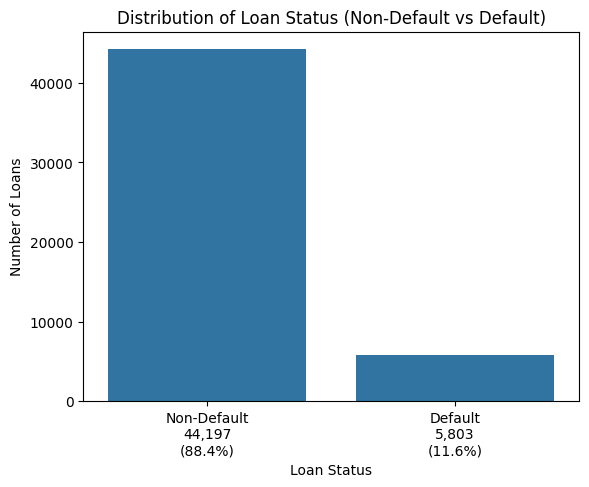

In [97]:
# Visualizing the distribution of the target variable (bad_status)
# to examine class imbalance between default and non-default loans
# 0 = Non-Default
# 1 = Default

import matplotlib.pyplot as plt
import seaborn as sns


counts = df_sample['bad_status'].value_counts().sort_index()
percentages = df_sample['bad_status'].value_counts(normalize=True).sort_index() * 100

labels = [
    f"Non-Default\n{counts[0]:,}\n({percentages[0]:.1f}%)",
    f"Default\n{counts[1]:,}\n({percentages[1]:.1f}%)"
]

ax = sns.countplot(x='bad_status', data=df_sample)

plt.xticks([0, 1], labels)
plt.xlabel('Loan Status')
plt.ylabel('Number of Loans')
plt.title('Distribution of Loan Status (Non-Default vs Default)')
plt.ticklabel_format(style='plain', axis='y')

plt.show()


The count plot illustrates the distribution of the target variable bad_status, which classifies loans as `non-default (0)` or `default (1`). The dataset is noticeably imbalanced, with non-default loans representing the majority of observations. Approximately 88.4% of loans fall into the non-default category, while about 11.6% are classified as default. This class imbalance is common in credit risk datasets and is important to consider during model development, as it may influence predictive performance and require techniques such as class weighting or resampling.

### Correlation Analysis

In [98]:
# Selecting key features for correlation analysis 
# with the target variable (bad_status)
key_vars = [
    'bad_status',

    # Loan characteristics
    'loan_amnt',
    'int_rate',
    'installment',
    'term',

    # Borrower financial profile
    'annual_inc',
    'dti',

    # Credit quality
    'grade_combined',

    # Credit history
    'credit_history_years',
    'delinq_2yrs',

    # Credit utilization
    'revol_util',

    # Account information
    'open_acc',
    'total_acc',

    # Time features
    'loan_age_years'
]

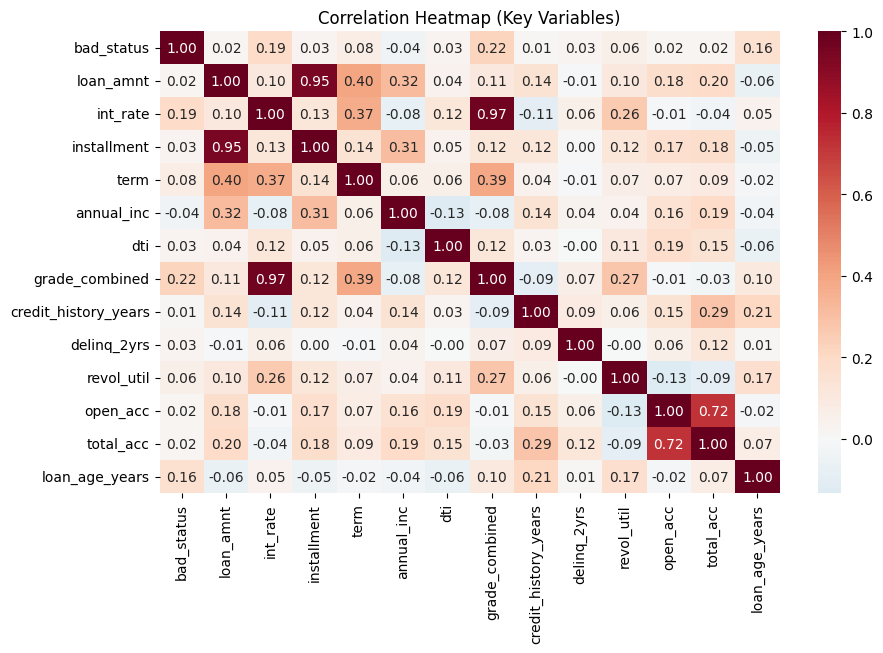

In [99]:
# Correlation heatmap of selected numerical variables
# used to examine relationships with the target variable

corr = df_sample[key_vars].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',   # better contrast (red vs blue)
    center=0,        # makes 0 neutral (white-ish)
    fmt=".2f"
)

plt.title('Correlation Heatmap (Key Variables)')
plt.show()

The correlation heatmap summarizes relationships among representative loan characteristics, borrower financial variables, credit history, and the target variable (`bad_status`). Among the selected features, `grade_combined` and `int_rate` exhibit the strongest positive correlations with loan default, indicating that borrowers with lower credit quality and higher interest rates are more likely to become delinquent. Most other variables show relatively weak individual correlations with the target, suggesting that no single predictor is sufficient to explain default risk. The heatmap also reveals strong correlations between several predictor variables, most notably `loan_amnt` and `installment`, `int_rate` and `grade_combined`, and `open_acc` and `total_acc`. These relationships indicate potential multicollinearity among some features, which should be considered during model development and interpretation.

### Interest Rate Analysis

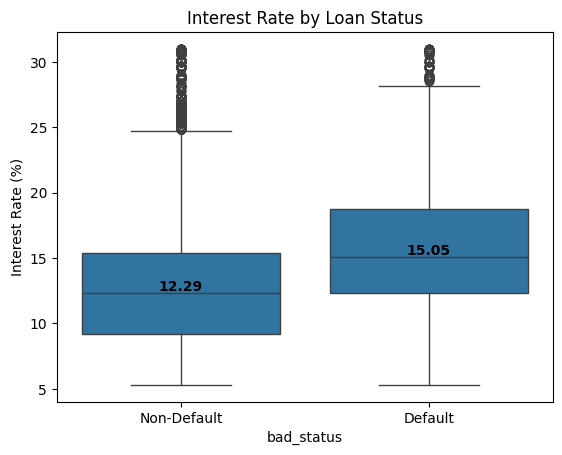

In [100]:
# Visualizing how interest rates differ between non-default and defaulted loans
# This helps assess whether borrowers with higher interest rates 
# are more likely to default

# Create the boxplot
sns.boxplot(x='bad_status', y='int_rate', data=df_sample)

# Calculate medians
medians = df_sample.groupby('bad_status')['int_rate'].median()

# Add median values to the plot
for i, median in enumerate(medians):
    plt.text(i, median, f'{median:.2f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Labels and title
plt.xticks([0, 1], ['Non-Default', 'Default'])
plt.ylabel('Interest Rate (%)')
plt.title('Interest Rate by Loan Status')

plt.show()

The boxplot shows that delinquent loans tend to have higher interest rates than non-delinquent loans. The median interest rate is clearly higher, and the overall distribution is shifted upward. This suggests that higher borrowing costs may be associated with an increased likelihood of falling behind on payments.

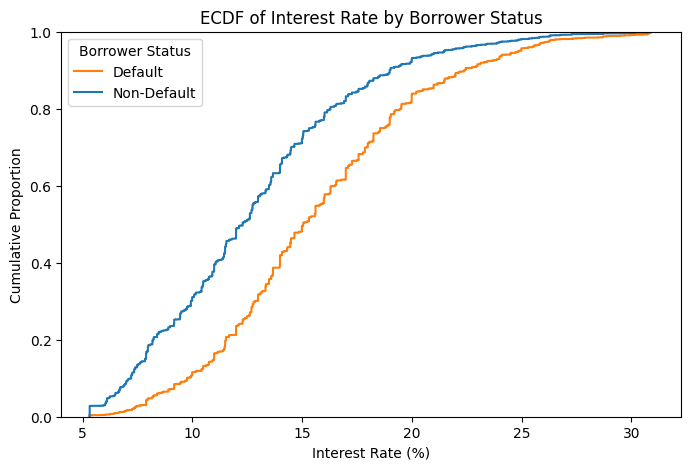

In [101]:
plt.figure(figsize=(8,5))

sns.ecdfplot(
    data=df_sample,
    x='int_rate',
    hue='bad_status'
)

plt.xlabel('Interest Rate (%)')
plt.ylabel('Cumulative Proportion')
plt.title('ECDF of Interest Rate by Borrower Status')

# Custom legend labels
plt.legend(
    labels=['Default', 'Non-Default'],
    title='Borrower Status'
)

plt.show()

This ECDF plot compares the distribution of interest rates between default and non-default borrowers. The default borrower distribution is shifted to the right, indicating that defaulted loans generally carry higher interest rates. In contrast, non-defaulted borrowers are more concentrated at lower interest rates. The visible separation between the two curves suggests that interest rate may be an important factor associated with borrower's delinquency and supports the earlier findings from the boxplot analysis.

### Loan Grade (Combined) Analysis

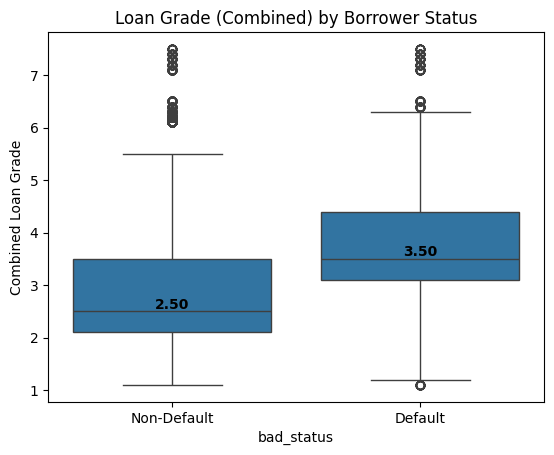

In [102]:
# Visualizing how loan grade differs between non-default and defaulted loans
# This helps evaluate whether lower credit quality 
# is associated with a higher risk of default

# Create the boxplot
sns.boxplot(x='bad_status', y='grade_combined', data=df_sample)

# Calculate medians
medians = df_sample.groupby('bad_status')['grade_combined'].median()

# Step 3: Add median values to the plot
for i, median in enumerate(medians):
    plt.text(i, median, f'{median:.2f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Labels and title
plt.xticks([0, 1], ['Non-Default', 'Default'])
plt.ylabel('Combined Loan Grade')
plt.title('Loan Grade (Combined) by Borrower Status')
plt.show()

This plot shows how the combined loan grade differs between non-defaulted and defaulted loans.

The median combined grade for defaulted loans (3.50 –> C5) is higher than that of non-defaulted loans (2.50 –> B5), indicating that borrowers with weaker credit profiles are more likely to ultimately default on their loans.

The overall distribution of grades for defaulted loans is shifted toward lower credit quality, suggesting that poorer loan grades are associated with greater default risk.

However, there is considerable overlap between the two groups. Some higher-risk loans remain non-defaulted, indicating that while loan grade is an important predictor of default, it does not fully determine loan outcomes. Many borrowers with weaker credit profiles are still able to meet their repayment obligations.

### Debt-to-Income Analysis (DTI)

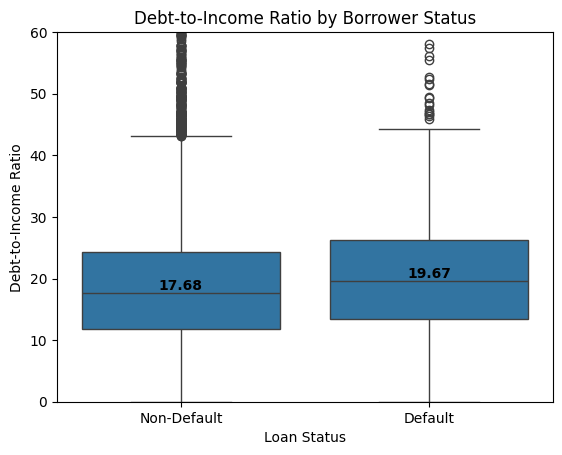

In [103]:
# Visualizing how DTI differs between non-default and defaulted loans
# The y-axis is limited because extreme outliers make the boxplot hard to read

sns.boxplot(x='bad_status', y='dti', data=df_sample)

# Calculate medians
medians = df_sample.groupby('bad_status')['dti'].median()

# Add median values
for i, median in enumerate(medians):
    plt.text(i, median, f'{median:.2f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Labels and title
plt.xticks([0, 1], ['Non-Default', 'Default'])
plt.ylabel('Debt-to-Income Ratio')
plt.xlabel('Loan Status')
plt.title('Debt-to-Income Ratio by Borrower Status')

# Limit y-axis to make the main distribution visible
plt.ylim(0, 60)

plt.show()

The box plot comparing debt-to-income (DTI) ratios shows that defaulted loans tend to have slightly higher DTI values than non-defaulted loans. The median DTI ratio is higher among defaulted loans, suggesting that borrowers with greater debt relative to their income may face a higher risk of default. However, the difference between the two groups is relatively modest, indicating that DTI alone may not be a strong predictor of default. Extreme outliers are present in the data, and the y-axis was limited to better visualize the main distribution.

### Annual Income Analysis

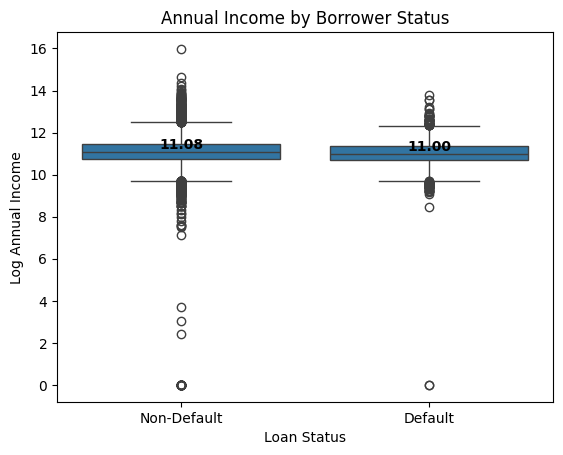

In [105]:
# Visualizing how annual income differs between non-default and defaulted loans
# Annual income is highly skewed, so log income is used to make the distribution easier to compare

df_sample['log_annual_inc'] = np.log1p(df_sample['annual_inc'])

sns.boxplot(x='bad_status', y='log_annual_inc', data=df_sample)

# Calculate medians
medians = df_sample.groupby('bad_status')['log_annual_inc'].median()

# Add median values
for i, median in enumerate(medians):
    plt.text(i, median, f'{median:.2f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Labels and title
plt.xticks([0, 1], ['Non-Default', 'Default'])
plt.ylabel('Log Annual Income')
plt.xlabel('Loan Status')
plt.title('Annual Income by Borrower Status')

plt.show()

The distribution of annual income is very similar between defaulted and non-defaulted loans. Median income levels are nearly identical, and there is substantial overlap between the two groups. This suggests that annual income alone does not have a strong direct relationship with default risk in this dataset. Because of the presence of extreme values, a logarithmic transformation was applied to improve visualization; however, even after the transformation, the differences between the groups remain minimal.

Overall, interest rate and loan grade exhibit stronger relationships with default risk, while variables such as annual income and debt-to-income ratio (DTI) appear to provide weaker predictive signals on their own. These variables may still contribute valuable information when combined with other features in a predictive model.

### Loan Purpose Distribution by Borrower Status

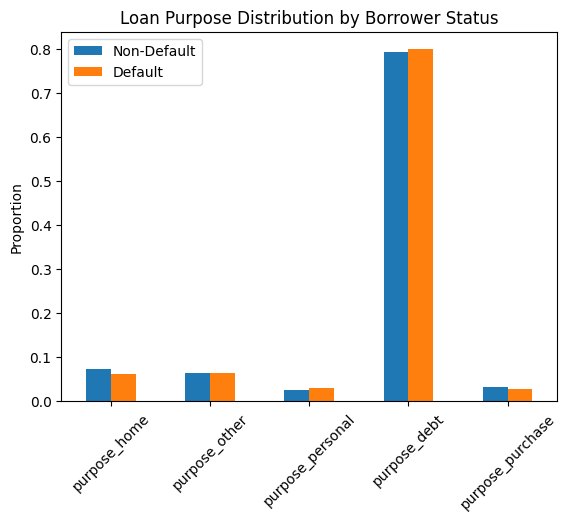

In [106]:
# Visualizing how loan purpose is associated with borrower delinquency
# Since loan purpose was one-hot encoded, we analyze the average proportion
# of each purpose category within delinquent and non-delinquent groups.
# This helps identify whether certain borrowing purposes are linked to higher risk.

purpose_cols = [
    'purpose_home',
    'purpose_other',
    'purpose_personal',
    'purpose_debt',
    'purpose_purchase'
]

# Calculate delinquency rate for each purpose
purpose_rates = df_sample.groupby('bad_status')[purpose_cols].mean().T

# Plot
purpose_rates.plot(kind='bar')
plt.title('Loan Purpose Distribution by Borrower Status')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(['Non-Default', 'Default'])
plt.show()

The distribution of loan purpose appears very similar between defaulted and non-defaulted borrowers. The majority of loans in both groups are associated with debt consolidation, and other categories show comparable proportions. This suggests that loan purpose does not have a strong relationship with default risk in this dataset.

## 5. Training Data Preparation

## 5.1 Feature and Target Selection
Before training the models, the dataset is split into two components. The first component, X, contains all of the information available about each loan, such as borrower characteristics and loan details. The second component, y, contains the target variable (bad_status), which tells the model whether each loan is classified as default or non-default. The goal of the model is to learn patterns in X that can accurately predict the values in y.

In [107]:
# Define the target variable (y)
# bad_status = 1 indicates a defaulted loan
# bad_status = 0 indicates a non-defaulted loan

y = df_sample['bad_status']

# Create the feature matrix (X)
# Remove the target variable so the model cannot use it to predict itself

X = df_sample.drop(columns=['bad_status'])

In [108]:
print(X.shape)
print(y.shape)

(50000, 76)
(50000,)


## 5.2 Train - Test Split

To evaluate how well the machine learning models generalize to unseen data, the dataset is divided into training and testing subsets. An 80/20 split is used, with **stratified** sampling to preserve the proportion of default and non-default loans in both sets. This helps ensure that the training and testing data remain representative of the original sample and allows for a fair evaluation of model performance.

In [109]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# The training set is used to train the model
# The testing set is used to evaluate how well the model performs on unseen data

# stratify=y preserves the original class distribution
# (approximately 80% non-default and 20% default) in both datasets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [110]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

bad_status
0    0.88395
1    0.11605
Name: proportion, dtype: float64
bad_status
0    0.8839
1    0.1161
Name: proportion, dtype: float64


In [111]:
X.isna().sum().sort_values(ascending=False).head(20)

loan_amnt              0
funded_amnt            0
funded_amnt_inv        0
term                   0
int_rate               0
installment            0
grade                  0
sub_grade              0
emp_length             0
annual_inc             0
verification_status    0
dti                    0
delinq_2yrs            0
inq_last_6mths         0
open_acc               0
pub_rec                0
revol_bal              0
revol_util             0
total_acc              0
initial_list_status    0
dtype: int64

## 5.3 Feature Scaling

Machine learning algorithms perform better when numerical features are measured on a similar scale. To account for differences in feature magnitude, the predictor variables are standardized using StandardScaler. The scaler is fitted only on the training data and then applied to both the training and testing sets, preventing information from the test data from influencing the training process and helping to avoid data leakage.

In [112]:
from sklearn.preprocessing import StandardScaler

# Standardize features before Logistic Regression

# Scaling transforms each feature so that:
# Mean = 0
# Standard Deviation = 1

# This prevents variables with larger numerical ranges
# from dominating variables with smaller ranges

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)